## HITL 1

In [1]:
from typing import TypedDict, Literal, Dict, Any
from langgraph.graph import StateGraph, END
from langchain_aws import ChatBedrockConverse
import json

In [2]:
# Define the state schema
class HumanInTheLoopState(TypedDict):
    question: str
    ai_draft: str
    human_feedback: str
    final_response: str

# Initialize models
llm = ChatBedrockConverse(model_id="cohere.command-r-plus-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=500)

In [3]:
# Node: AI drafts initial response
def draft_response(state: Dict[str, Any]) -> Dict[str, Any]:
    question = state["question"]
    response = llm.invoke(f"Draft a helpful response to: {question}")
    print(f"\n AI Drafted Response:\n{response.content}\n")
    return {"ai_draft": response.content}

# Node: Human provides feedback
def get_human_feedback(state: Dict[str, Any]) -> Dict[str, Any]:
    print("\n HUMAN REVIEW REQUIRED")
    print(f"Question: {state['question']}")
    print(f"AI Draft: {state['ai_draft']}")
    feedback = input("\nEnter feedback or type 'approve' to accept: ")
    return {"human_feedback": feedback}

# Node: Decide next step based on feedback
def decide_next_step(state: Dict[str, Any]) -> Literal["revise", "finalize"]:
    if state["human_feedback"].strip().lower() == "approve":
        return "finalize"
    return "revise"

# Node: Revise response using feedback
def revise_response(state: Dict[str, Any]) -> Dict[str, Any]:
    prompt = (
        f"Revise the following response based on this feedback:\n"
        f"Response: {state['ai_draft']}\n"
        f"Feedback: {state['human_feedback']}"
    )
    revised = llm.invoke(prompt)
    print(f"\n Revised Response:\n{revised.content}\n")
    return {"ai_draft": revised.content}

# Node: Finalize response
def finalize_response(state: Dict[str, Any]) -> Dict[str, Any]:
    final = f"FINAL RESPONSE:\n{state['ai_draft']}"
    print(f"\n Final Response Ready:\n{final}\n")
    return {"final_response": final}

In [4]:


# Build the LangGraph workflow
def create_hitl_graph():
    graph = StateGraph(HumanInTheLoopState)
    graph.add_node("draft", draft_response)
    graph.add_node("human_review", get_human_feedback)
    graph.add_node("revise", revise_response)
    graph.add_node("finalize", finalize_response)

    graph.add_edge("draft", "human_review")
    graph.add_conditional_edges("human_review", decide_next_step, {
        "revise": "revise",
        "finalize": "finalize"
    })
    graph.add_edge("revise", "human_review")
    graph.add_edge("finalize", END)

    graph.set_entry_point("draft")
    # print(graph.compile())
    return graph.compile()



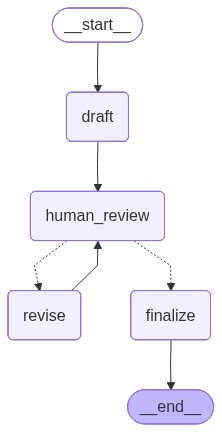

In [6]:
create_hitl_graph()

In [7]:
# Run the workflow
if __name__ == "__main__":
    workflow = create_hitl_graph()
    initial_state = {
        "question": "How can I implement a human-in-the-loop system in AI?",
        "ai_draft": "",
        "human_feedback": "",
        "final_response": ""
    }

    for _ in workflow.stream(initial_state):
        pass

    print("\n WORKFLOW COMPLETED")


 AI Drafted Response:
Human-in-the-Loop (HITL) systems are a type of human-machine collaboration where human input and decision-making are integrated into the AI workflow. Implementing a HITL system can provide benefits such as improved accuracy, adaptability, and ethical decision-making. Here are some steps and strategies to help you design and implement an effective HITL system:

1. Define the Problem and Scope: Clearly understand and define the problem you are trying to solve or the process you want to improve with the HITL system. Identify the specific tasks where human input is necessary or can provide value.

2. Determine Human Roles: Decide on the level of human involvement and the specific roles humans will play in the system. Humans can act as reviewers, providing feedback and corrections, or they can be active participants, making decisions and guiding the AI in real time.

3. Design Human Interfaces: Create user-friendly interfaces that allow humans to interact effectively 


Enter feedback or type 'approve' to accept:  reduce content to 100 words



 Revised Response:
Here is a revised version of your response, trimmed down to 100 words: 

"Human-in-the-Loop (HITL) systems offer improved accuracy and adaptability by integrating human input with AI workflows. To design an effective HITL system: 

- Define the problem and scope: Identify tasks requiring human input.
- Determine human roles: Decide on reviewer or active participant roles.
- Design intuitive interfaces: Ensure efficient human-AI interaction. 
- Collect and manage data: Ensure data quality and ethical considerations. 
- Choose AI techniques: Align with the problem and desired human interaction level. 
- Implement feedback loops: Use human input to improve the AI model. 
- Ensure human oversight: Address biases and ethical dilemmas with review mechanisms."

This revised version maintains the key points while adhering to the word limit.


 HUMAN REVIEW REQUIRED
Question: How can I implement a human-in-the-loop system in AI?
AI Draft: Here is a revised version of your re


Enter feedback or type 'approve' to accept:  approve



 Final Response Ready:
FINAL RESPONSE:
Here is a revised version of your response, trimmed down to 100 words: 

"Human-in-the-Loop (HITL) systems offer improved accuracy and adaptability by integrating human input with AI workflows. To design an effective HITL system: 

- Define the problem and scope: Identify tasks requiring human input.
- Determine human roles: Decide on reviewer or active participant roles.
- Design intuitive interfaces: Ensure efficient human-AI interaction. 
- Collect and manage data: Ensure data quality and ethical considerations. 
- Choose AI techniques: Align with the problem and desired human interaction level. 
- Implement feedback loops: Use human input to improve the AI model. 
- Ensure human oversight: Address biases and ethical dilemmas with review mechanisms."

This revised version maintains the key points while adhering to the word limit.


 WORKFLOW COMPLETED
